# IT3103 Practical 05/07a: Human Activity Recognition using 2D-Pose and RNN

In this practical, we will be developing a model to recognise activities such as jumping, boxing, waving one hand, etc. The activity is defined as a sequence of human poses (given by keypoints of skeletal joints) and these poses are estimated by a pretrained model (Google's PoseNet).


## Section 1 - Import Libraries and Setup Folders

Let's import all the necessary libraries

In [1]:
import pandas as pd
import os
import numpy as np
import math
from tqdm import tqdm
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import rc

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Input, Bidirectional, Dropout, LSTM, TimeDistributed, Flatten


## Section 2 - Dataset

We will be using the following dataset from 
https://github.com/stuarteiffert/RNN-for-Human-Activity-Recognition-using-2D-Pose-Input

The data is 2D positions (x,y coordinates) of 18 joints across a timeseries of 32 frames (window-width), with an associated class label for the frame series.

The dataset consist of the following files:
- X_test.txt : testing dataset x inputs (36 keypoints per line, 32 lines per datapoint)
- X_train.txt : training dataset x inputs (36 keypoints per line, 32 lines per datapoint)
- X_val.txt : validation dataset x inputs (36 keypoints per line, 32 lines per datapoint)
- Y_test.txt : testing class labels
- Y_train.txt : training class labels
- Y_val.txt : validation class labels

In [2]:
!wget https://nyp-aicourse.s3.ap-southeast-1.amazonaws.com/it3103/2D-Pose-Data.zip
!unzip 2D-Pose-Data.zip

'wget' is not recognized as an internal or external command,
operable program or batch file.
'unzip' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
# !powershell -Command "Invoke-WebRequest https://nyp-aicourse.s3.ap-southeast-1.amazonaws.com/it3103/2D-Pose-Data.zip -OutFile 2D-Pose-Data.zip"
# !powershell -Command "Expand-Archive -Path 2D-Pose-Data.zip

In [ ]:
# train_df = pd.read_csv('2D-Pose-Data/2D-Pose-Data/X_train.txt', header=None)
# train_label_df = pd.read_csv('2D-Pose-Data/2D-Pose-Data/Y_train.txt', header=None)
# test_df = pd.read_csv('2D-Pose-Data/2D-Pose-Data/X_test.txt', header=None)
# test_label_df = pd.read_csv('2D-Pose-Data/2D-Pose-Data/Y_test.txt', header=None)

In [7]:
train_df = pd.read_csv('2D-Pose-Data/X_train.txt', header=None)
train_label_df = pd.read_csv('2D-Pose-Data/Y_train.txt', header=None)
test_df = pd.read_csv('2D-Pose-Data/X_test.txt', header=None)
test_label_df = pd.read_csv('2D-Pose-Data/Y_test.txt', header=None)

FileNotFoundError: [Errno 2] No such file or directory: '2D-Pose-Data/X_train.txt'

In [11]:
#print the first data point which consists of 32 rows
train_df[:32]


,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,295.914,161.579,307.693,203.413,281.546,203.368,274.997,251.562,267.194,293.253,...,328.528,411.922,294.546,156.420,305.002,156.418,0.000,0.000,318.083,161.632
1,295.855,161.600,307.684,203.408,281.529,203.385,274.989,251.574,267.191,291.961,...,328.493,410.630,293.252,157.686,303.706,157.706,0.000,0.000,318.024,161.654
2,293.296,161.620,307.655,203.410,280.228,203.382,274.986,251.591,267.262,289.373,...,328.522,411.946,289.374,157.686,299.798,157.714,0.000,0.000,316.776,161.679
3,291.978,161.658,307.619,204.678,278.918,204.659,275.001,254.114,269.794,289.363,...,328.479,411.947,288.101,157.727,298.487,158.985,0.000,0.000,316.720,161.697
4,288.063,168.120,306.362,209.835,276.384,211.108,275.010,255.461,275.003,294.581,...,329.774,411.884,286.774,161.596,297.133,161.601,0.000,0.000,315.402,166.840
5,288.099,170.803,306.305,212.481,276.344,212.513,274.976,256.760,271.103,295.838,...,329.755,411.865,286.770,164.264,297.175,166.822,0.000,0.000,314.141,172.008
6,286.754,177.256,306.262,216.405,276.275,216.395,274.998,263.298,273.732,297.230,...,329.758,413.198,285.441,170.791,295.863,170.811,0.000,0.000,310.225,175.990
7,285.416,183.790,305.021,224.264,275.087,224.231,274.978,268.494,273.674,301.093,...,328.473,413.208,282.858,179.879,294.535,181.121,0.000,0.000,308.929,183.805
8,282.824,194.243,303.713,233.378,275.053,233.362,275.000,276.353,275.039,312.839,...,332.392,413.223,278.916,191.553,289.348,191.540,0.000,0.000,307.609,192.948
9,282.831,203.294,299.823,241.135,274.970,241.154,274.999,286.731,275.053,327.171,...,329.780,411.952,277.651,196.820,288.108,196.811,0.000,0.000,307.566,201.976


In [12]:
#check the distribution of the labels
train_label_df.value_counts()

0
5    5055
4    4760
3    4724
2    3545
1    2400
6    2141
Name: count, dtype: int64

In [13]:
labels = ["JUMPING", "JUMPING_JACKS", "BOXING", "WAVING_2HANDS", "WAVING_1HAND", "CLAPPING_HANDS"]

## Section 3- Create the input data

We cannot use the panda dataframe (which is 2D) directly with our LSTM network. We need to create a dataset that consists sequence of 32 timesteps (frames) of 36 keypoints. In other words, we need our data to be of the shape (batch_size, 32, 36).

In addition, we saw earlier that our labels starts from 1 to 6 (total of 6 classes). However, the deep learning model will predict labels starting from 0 to 5.  So we need to map the labels to 0-5 by subtracting the original values by 1. 

Our labels are the following: 

```
labels = ["JUMPING", "JUMPING_JACKS", "BOXING", "WAVING_2HANDS", "WAVING_1HAND", "CLAPPING_HANDS"]
```

In [14]:
# convert the dataframe to numpy array and bunch every 32 rows together as a sequence of 32 timesteps
X_train = train_df.to_numpy().reshape(-1, 32, 36)

# convert labels from 1-6 to 0-5.
y_train = train_label_df.to_numpy() - 1

print(X_train.shape)
print(y_train.shape)

(22625, 32, 36)
(22625, 1)


In [15]:
X_test = test_df.to_numpy().reshape(-1, 32, 36)
y_test = test_label_df.to_numpy() - 1

print(X_test.shape)
print(y_test.shape)

(5751, 32, 36)
(5751, 1)


## Section 4 - Visualize Our Dataset



We can view each frame as a timestep on the x-axis, and each of the 36 numbers (the x and y coordinates of 18 joints) as individual line plots.  It provides some visual clue as to how the different joints move over time, but they are still difficult to imagine and visualize.

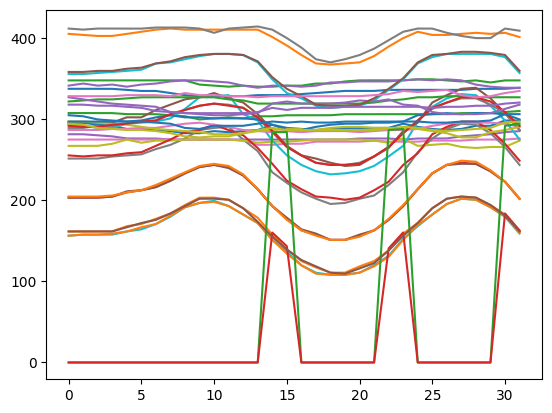

In [16]:
%matplotlib inline 
sample = 0
plt.plot(X_train[sample])
plt.show()

A better way to visualize is do a scatter plot of the X and Y coordianates of the various joints and animating them so that we can see their movements over time.

NOTE: These are the various types of actions captured in the dataset:
JUMPING, JUMPING_JACKS, BOXING, WAVING_2HANDS, WAVING_1HAND", "CLAPPING_HANDS"

In [17]:
sample = 0

# This function returns a set of data for every frame that is
# called from the animation.FuncAnimation below.
#
def animate_pose(frame):
    # Retrieve the even number values as X-coordinates
    # and the odd number values as Y-coordinates
    #
    # Once you have these 2 sets of values, you can
    # pass them into the line.set_data to get matplotlib
    # to draw a scatter plot 
    #
    graph_x = X_train[sample][frame][0::2]
    graph_y = X_train[sample][frame][1::2]
    line.set_data(graph_x, graph_y)
    return line,

fig, ax = plt.subplots()
plt.close()

ax.set_xlim(0, 800)
ax.set_ylim(600, 0)

line, = ax.plot([], [], 'o', color='black');

anim = animation.FuncAnimation(fig, animate_pose, 32,  interval=50, blit=True)
rc('animation', html='jshtml')
anim

## Section 5 - Define and Train Your Model

We will next create a model using LSTM layer to process sequence (time-series) data. We will start with very simple model, consisting of only a single LSTM layer followed by Dense layer for classification. We will also add in Dropout layer. 

Since our target label is not one-hot-encoded, we will specify `sparse_categorical_crossentropy` as our loss function.

You may find that a good validation accuracy for you model may hover near about 85-90%. 

In [18]:
# Create our LSTM model here
#
def create_model():

    # Use Keras to create a Sequential model here with any layers that 
    # you'd like.
    #
    model = Sequential()

    model.add(LSTM(128, input_shape=(32, 36)))
    model.add(Dropout(0.2))

    model.add(Dense(6, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.summary()
    return model


In [19]:
model = create_model()

# create tensorboard log directory 
root_logdir = os.path.join(os.curdir, "tb_logs")

def get_run_logdir():    # use a new directory for each run
    import time
    run_id = time.strftime("run_%Y_%m_%d-%H_%M_%S")
    logdir = os.path.join(root_logdir, run_id)
    os.makedirs(logdir, exist_ok=True)
    return logdir 

run_logdir = get_run_logdir()
tensorboard_callback = keras.callbacks.TensorBoard(log_dir=run_logdir)
checkpoint_callback = keras.callbacks.ModelCheckpoint(filepath=run_logdir + '/model.{epoch:04d}-val_acc-{val_accuracy:4.2f}-loss-{val_loss:4.2f}.keras',
                                                      monitor='val_loss', save_best_only=True)
earlystop_callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train our model
#
model.fit(x=X_train, y=y_train, 
          batch_size=256, 
          epochs=40,
          validation_data=(X_test, y_test),
          callbacks=[tensorboard_callback, checkpoint_callback, earlystop_callback], 
          verbose=1)

c:\Users\liangnanyi\.conda\envs\IT3103\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,254 (333.02 KB)

 Trainable params: 85,254 (333.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - accuracy: 0.3428 - loss: 1.6390 - val_accuracy: 0.4582 - val_loss: 1.4982
Epoch 2/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.4491 - loss: 1.4478 - val_accuracy: 0.5216 - val_loss: 1.3355
Epoch 3/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.5131 - loss: 1.3086 - val_accuracy: 0.5935 - val_loss: 1.2242
Epoch 4/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.5706 - loss: 1.1783 - val_accuracy: 0.6555 - val_loss: 1.0891
Epoch 5/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.6163 - loss: 1.0673 - val_accuracy: 0.6936 - val_loss: 0.9903
Epoch 6/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.6565 - loss: 0.9685 - val_accuracy: 0.7315 - val_loss: 0.8678
Epoch 7/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.6926 - loss: 0.8732 - val_accuracy: 0.7501 - val_loss: 0.7941
Epoch 8/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.7088 - loss: 0.8209 - val_accuracy: 0.7508 - v

In [20]:
%load_ext tensorboard 
%tensorboard --logdir tb_logs

## Section 6 - Scale / Translation Normalization

So far, we have not talked about how we can normalize our skeletal keypoints so that the pose data is scale / translation invariant. This means that regardless of how far the person is from the camera, or when the person moves left or right or up or down, the coordinates of all joint positions should always be relative to a fixed frame of reference.

To take care of translation (left / right / up / down) invariance, we are shift all points together so that neck point is always placed at (0, 0). 

To take care of scale invariance, we estimate the torso height (which is either the length of the neck point to either hip, or the width of the shoulders). We then divide all joint coordinates by the torso height.

To do so, we will create a `process_joints()` function to include code to normalize the skeleton key points as described above:

1. ref = P[1] or the midpoint of P[2], P[5]
2. reflength = length(ref to P[8]) or length(ref to P[11]) 
3. Compute 
   - P[i].x = (P[i].x - ref.x) / reflength
   - P[i].y = (P[i].y - ref.y) / reflength


In [21]:
# Declare a function that can compute length (euclidean distance) between two points
#   (x1,y1) - (x2,y2)
def compute_length(x1, y1, x2, y2):
    return math.sqrt((x1-x2)*(x1-x2) + (y1-y2)*(y1-y2))

# Process OpenPose's Joints

# NOTE: The "keypoints" parameter consists of an array of consecutive x and y values 
# within the same array.
# keypoints = [p0.x, p0.y, p1.x, p1.y, p2.x, p2.y, ..., p17.x, p17.y] (a total of 36 values) 
def process_joints(keypoints):

    normalized_keypoints = [0] * 36

    refx = 0
    refy = 0
    reflength = 1

    # Step 1: Let's find the reference point (neck)
    #
    if keypoints[2] != 0 or keypoints[3] != 0:         
        refx = keypoints[2]                # use the neck X, Y
        refy = keypoints[3]
    elif (keypoints[4] != 0 or keypoints[5] != 0) and (keypoints[10] != 0 or keypoints[11] != 0):
        refx = (keypoints[4] + keypoints[10]) / 2  # estimate the neck X, Y from the mid point
        refy = (keypoints[5] + keypoints[11]) / 2  # of the left/right shoulder
    
    # Step 2: Let's estimate the torso length.
    #
    if keypoints[16] != 0 and keypoints[17] != 0:             
        reflength = compute_length(keypoints[16], keypoints[17], refx, refy)   # neck to right hip
    elif keypoints[22] != 0 and keypoints[23] != 0:
        reflength = compute_length(keypoints[22], keypoints[23], refx, refy)   # neck to left hip

    # Step 3:
    # Perform the translation and the scaling.
    #
    for i in range(0, 18):
        normalized_keypoints[i*2] = (keypoints[i*2] - refx) / reflength
        normalized_keypoints[i*2 + 1] = (keypoints[i*2 + 1] - refy) / reflength
    
    # Return the re-mapped and normalized result
    #
    return normalized_keypoints


We will apply the normalization to each row of keypoints (36 keypoints). We use `itertuples()` to iterate through each row of dataframe. 

In [22]:
def normalize(df):
    X = []
    for row in tqdm(df.itertuples(index=False)):
        X.append(process_joints(row))
    
    X = np.array(X)
    return X

In [23]:
X_train_normalized = normalize(train_df).reshape(-1, 32, 36)
X_test_normalized = normalize(test_df).reshape(-1, 32, 36)

724000it [00:07, 101996.05it/s]
184032it [00:01, 125178.64it/s]


In [24]:
model = create_model()

run_logdir = get_run_logdir()
tensorboard_callback = keras.callbacks.TensorBoard(log_dir=run_logdir)
checkpoint_callback = keras.callbacks.ModelCheckpoint(filepath=run_logdir + '/model.{epoch:04d}-val_acc-{val_accuracy:4.2f}-loss-{val_loss:4.2f}.keras',
                                                      monitor='val_loss', save_best_only=True)
earlystop_callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train our model
model.fit(x=X_train_normalized, y=y_train, 
          batch_size=256, 
          epochs=40,
          validation_data=(X_test_normalized, y_test),
          callbacks=[tensorboard_callback, checkpoint_callback, earlystop_callback], 
          verbose=1)


c:\Users\liangnanyi\.conda\envs\IT3103\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,254 (333.02 KB)

 Trainable params: 85,254 (333.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - accuracy: 0.7153 - loss: 0.7271 - val_accuracy: 0.8538 - val_loss: 0.3537
Epoch 2/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9078 - loss: 0.2541 - val_accuracy: 0.9117 - val_loss: 0.2381
Epoch 3/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9452 - loss: 0.1556 - val_accuracy: 0.9515 - val_loss: 0.1413
Epoch 4/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9581 - loss: 0.1210 - val_accuracy: 0.9598 - val_loss: 0.1280
Epoch 5/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 62ms/step - accuracy: 0.9722 - loss: 0.0828 - val_accuracy: 0.9536 - val_loss: 0.1438
Epoch 6/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.9744 - loss: 0.0758 - val_accuracy: 0.9623 - val_loss: 0.1195
Epoch 7/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.9844 - loss: 0.0472 - val_accuracy: 0.9581 - val_loss: 0.1272
Epoch 8/40
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.9800 - loss: 0.0603 - val_accuracy: 0.9654 - v

## Section 7 - Evaluate Model Performance

(22625, 32, 36)
708/708 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


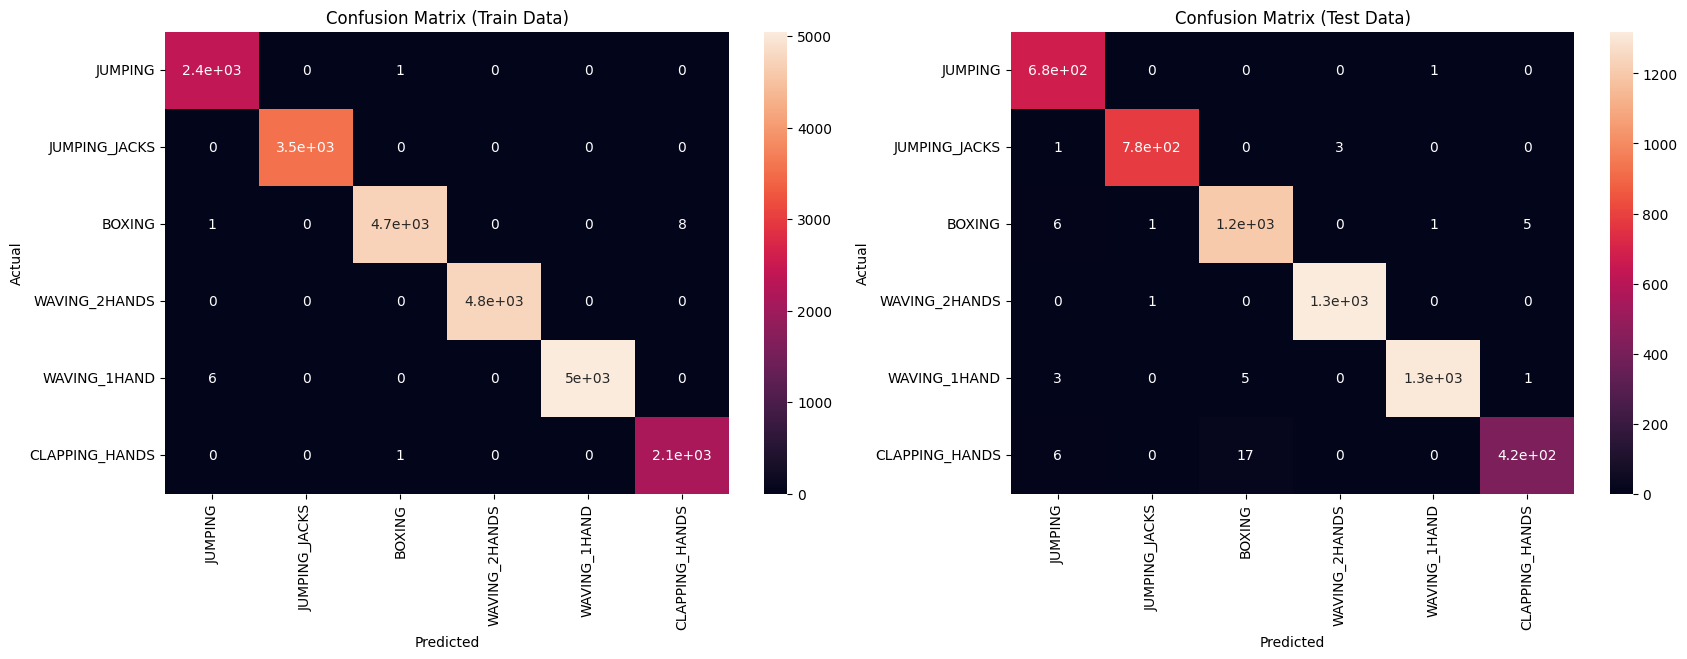

Train Data:
--------------------------------------------------------
                precision    recall  f1-score   support

       JUMPING       1.00      1.00      1.00      2400
 JUMPING_JACKS       1.00      1.00      1.00      3545
        BOXING       1.00      1.00      1.00      4724
 WAVING_2HANDS       1.00      1.00      1.00      4760
  WAVING_1HAND       1.00      1.00      1.00      5055
CLAPPING_HANDS       1.00      1.00      1.00      2141

      accuracy                           1.00     22625
     macro avg       1.00      1.00      1.00     22625
  weighted avg       1.00      1.00      1.00     22625


Test Data:
--------------------------------------------------------
                precision    recall  f1-score   support

       JUMPING       0.98      1.00      0.99       676
 JUMPING_JACKS       1.00      0.99      1.00       783
        BOXING       0.98      0.99      0.99      1216
 WAVING_2HANDS       1.00      1.00      1.00      1320
  WAVING_1HAND    

In [27]:
labels = ["JUMPING", "JUMPING_JACKS", "BOXING", "WAVING_2HANDS", "WAVING_1HAND", "CLAPPING_HANDS"]

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
 
def display_classification_confusion_matrix(keras_model, x_train, y_train, x_test, y_test, labels):
    
    '''
    x_train = []
    x_test = []
    y_train = []
    y_test = []
    '''
 
    print(x_train.shape)
    train_preds = keras_model.predict(x_train)
    test_preds = keras_model.predict(x_test)
    train_preds = np.argmax(train_preds, axis=1)
    test_preds = np.argmax(test_preds, axis=1)
    
    plt.figure(figsize=(20,6))  

    labels = np.array(labels)
    # Print the first Confusion Matrix for the training data
    #
    cm = confusion_matrix(y_train, train_preds)

    cm_df = pd.DataFrame(cm, labels, labels)          
    plt.subplot(1, 2, 1)
    plt.title('Confusion Matrix (Train Data)')
    sns.heatmap(cm_df, annot=True)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')        
    
    # Print the second Confusion Matrix for the test data
    #    
    cm = confusion_matrix(y_test, test_preds)
    
    cm_df = pd.DataFrame(cm, labels, labels)          
    plt.subplot(1, 2, 2)
    plt.title('Confusion Matrix (Test Data)')
    sns.heatmap(cm_df, annot=True)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')        
    
    plt.show()

    # Finally display the classification reports
    #
    print ("Train Data:")
    print ("--------------------------------------------------------")
    print(classification_report(y_train, train_preds, target_names=labels))
    print ("")
    print ("Test Data:")
    print ("--------------------------------------------------------")
    print(classification_report(y_test, test_preds, target_names=labels))
    

display_classification_confusion_matrix(model, X_train_normalized, y_train, X_test_normalized, y_test, labels)

## Section 8 - Save and Download Model

Run the following cell to save your model. 


In [28]:
model.save("activity_model.keras")

Run the following the zip the "model.savedmodel" folder into a single zip file.

Download that zip file from Colab once you are done! We will be using this for the next practical exercise.

In [29]:
!zip activity_model.zip -r activity_model.keras

'zip' is not recognized as an internal or external command,
operable program or batch file.


In [30]:
model = keras.models.load_model('activity_model.keras')

In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 255,764 (999.08 KB)

 Trainable params: 85,254 (333.02 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 170,510 (666.06 KB)

In [32]:
sample_index = 2000
sample = X_test_normalized[sample_index]
label = np.squeeze(y_test)[sample_index]


In [33]:
sample = np.expand_dims(sample, axis=0)

In [34]:
pred = model(sample)
print(pred)

tf.Tensor(
[[1.2759177e-06 4.3100390e-06 9.9998486e-01 1.0183902e-07 3.2831537e-08
  9.4559846e-06]], shape=(1, 6), dtype=float32)


In [35]:
print('actual = {}'.format(labels[label]))
print('predicted = {}'.format(labels[np.argmax(pred)]))

actual = BOXING
predicted = BOXING
